## sklearn Simple LR

In [9]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [16]:
X,Y=make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=50)

In [17]:
df=pd.DataFrame({'feature ':X[:,0],'target':Y})

In [18]:
df.head()

,feature,target
0,0.551201,62.066204
1,0.286412,73.796035
2,-0.169476,-88.834210
3,0.591455,47.230941
4,-0.547421,-8.518059


Text(0, 0.5, 'target')

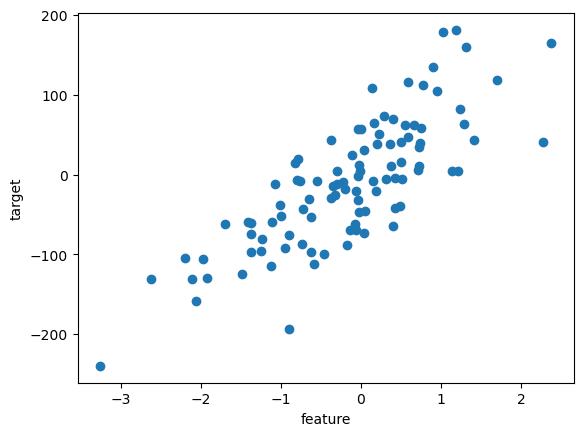

In [19]:
plt.scatter(X,Y)
plt.xlabel('feature')
plt.ylabel('target')

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [22]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [32]:
y_pred=lr.predict(x_test)
y_pred[0]

np.float64(-69.98140493066239)

In [24]:
print("slope:",lr.coef_)
print("intercept",lr.intercept_)

slope: [63.31494966]
intercept 0.2466626425124545


## My Simple LR

In [33]:
class SLR:
    def __init__(self):
        self.m=None
        self.b=None

    def fit(self,x_train,y_train):
        #slope term
        num=0
        den=0
        for i in range(x_train.shape[0]):
            num=num+((x_train[i]-x_train.mean()))*((y_train[i]-y_train.mean()))
            den=den+((x_train[i]-x_train.mean()))*((x_train[i]-x_train.mean()))
        self.m=num/den

        #intercept term
        self.b=y_train.mean()-(self.m*x_train.mean())

        
        print(self.m)
        print(self.b)

    def predict(self,x_test):
        return self.m*x_test+self.b

In [34]:
slr=SLR()

In [36]:
slr.fit(x_train,y_train)

[63.31494966]
[0.24666264]


In [37]:
slr.predict(x_test[0])

array([-69.98140493])

## sklearn multiple LR

In [38]:
X,Y=make_regression(n_samples=100,n_features=2,n_informative=2,n_targets=1,noise=50)

In [39]:
df=pd.DataFrame({'feature 1':X[:,0],'feature 2':X[:,1],'target':Y})

In [40]:
df.head()

,feature 1,feature 2,target
0,0.340016,1.447409,91.444872
1,0.298002,0.653715,7.128105
2,-0.384142,0.896431,128.205916
3,0.157853,-0.258094,4.722034
4,0.556913,-0.597753,-84.915713


In [41]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [42]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [44]:
y_pred=lr.predict(x_test)
y_pred[0]

np.float64(-4.251571633660947)

In [46]:
print("weights:",lr.coef_)
print("beta_0",lr.intercept_)

weights: [48.7774003  60.26129422]
beta_0 -6.321574785819965


In [51]:
x_train.shape

(80, 2)

## My Multiple LR

In [62]:
class MLR:
    def __init__(self):
        self.weights=None
        self.beta_0=None

    def fit(self,x_train,y_train):
        x_train=np.insert(x_train,0,1,axis=1)

        #weights
        beta=np.linalg.inv(np.dot(x_train.T,x_train)).dot(x_train.T).dot(y_train)
        self.beta_0=beta[0]
        self.weights=beta[1:]

        print(self.beta_0)
        print(self.weights)

    def predict(self,x_test):
        return np.dot(self.weights,x_test)+self.beta_0
        

In [63]:
#np.insert(x_train,0,1,axis=1).shape

In [64]:
mlr=MLR()

In [65]:
mlr.fit(x_train,y_train)

-6.321574785819967
[48.7774003  60.26129422]


In [66]:
mlr.predict(x_test[0])

np.float64(-4.251571633660985)